## Etude de données issues de plusieurs runs
Dans ce notebook on s'interesse à plusieurs run où on cherche à mettre en évidence le J/Psi

In [1]:
import math
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import awkward as ak
import hist
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import uproot
import vector
import time

vector.register_awkward()

print("uproot version", uproot.__version__)
print("awkward version", ak.__version__)
print("numpy version", np.__version__)
print("matplotlib version", matplotlib.__version__)
print("hist version", hist.__version__)
print("vector version", vector.__version__)
!ls -alh /pbs/throng/training/nantes-m2-rps-exp/data/*291263*

uproot version 5.5.1
awkward version 2.7.2
numpy version 2.1.3
matplotlib version 3.9.0
hist version 2.8.0
vector version 1.5.2
-rwxrwxr-x 1 2830 training 414M Aug 30  2023 /pbs/throng/training/nantes-m2-rps-exp/data/run291263.data.root
-rwxrwxr-x 1 2830 training  26M Aug 30  2023 /pbs/throng/training/nantes-m2-rps-exp/data/run291263.mc.root


In [2]:
import uproot
import glob
import os
liens = []
# Chemin vers le dossier contenant les fichiers
folder_path = "/pbs/throng/training/nantes-m2-rps-exp/data/"

# Trouver tous les fichiers .data.root
file_paths = glob.glob(os.path.join(folder_path, "*.data.root"))

# Vérifier si des fichiers ont été trouvés
if not file_paths:
    print("Aucun fichier .data.root trouvé.")
else:
    print(f"{len(file_paths)} fichiers trouvés.")

# Parcourir et ouvrir chaque fichier pour afficher ses clés
for file_path in file_paths:
    liens.append(file_path)
print(liens[:2])


166 fichiers trouvés.
['/pbs/throng/training/nantes-m2-rps-exp/data/run290428.data.root', '/pbs/throng/training/nantes-m2-rps-exp/data/run291447.data.root']


## Définitions des fonctions utilisées pour les exploitations de données

In [3]:

def donnees_masses_invarientes (lien_du_run):

##Cette fonction prend en entrée le lien d'un RUN et en ressort les valeurs de masses invariantes pour ce run sous forme de liste
    file = uproot.open(lien_du_run)
    file.keys()
    events = file["eventsTree"]
    m = events.arrays(
        [
            "nMuons",
            "Muon_Px",
            "Muon_Py",
            "Muon_Pz",
            "Muon_Charge",
            "Muon_E",
            "isCMUL",
            "zVtx",
            "Muon_matchedTrgThreshold",
            "isCMSH",
            "isCMLL",
            "Muon_yDCA",
            "Muon_thetaAbs",
        ],
        how="zip",
    )
    
    filtered_events = m[(m.nMuons >= 2) & (abs(m.zVtx) < 10) & (m.isCMUL)]
    
    # Initialiser les vecteurs des muons
    muon_vectors = ak.zip(
        {
            "px": filtered_events.Muon.Px,
            "py": filtered_events.Muon.Py,
            "pz": filtered_events.Muon.Pz,
            "E": filtered_events.Muon.E,
            "matchedTrgThreshold": filtered_events.Muon.matchedTrgThreshold,
            "DCA": filtered_events.Muon.yDCA,
            "charge": filtered_events.Muon.Charge,
            "theta": filtered_events.Muon.thetaAbs,
        },
        with_name="Momentum4D",
    )

    
    # Combinaisons de paires
    muon_pairs = ak.combinations(muon_vectors, 2, fields=["muon1", "muon2"])
    
    # Paires de charges opposées et filtrage
    opposite_charge_pairs = muon_pairs[
        (muon_pairs.muon1.charge != muon_pairs.muon2.charge)
        #& (muon_pairs.muon1.matchedTrgThreshold == 2)
        #& (muon_pairs.muon2.matchedTrgThreshold == 2)
        & (muon_pairs.muon1.theta <= 10)
        & (muon_pairs.muon2.theta <= 10)
        & (muon_pairs.muon1.theta >= 3)
        & (muon_pairs.muon2.theta >= 3)
        & (muon_pairs.muon1.eta <= -2.5)
        & (muon_pairs.muon1.eta <= -2.5)
        & (muon_pairs.muon2.eta >= -4)
        & (muon_pairs.muon2.eta >= -4)
    ]
    
    # Calcul des masses invariantes et de la rapidité
    masses_opposite = (opposite_charge_pairs.muon1 + opposite_charge_pairs.muon2).mass
    y_pair = (opposite_charge_pairs.muon1 + opposite_charge_pairs.muon2).rapidity
    
    # Appliquer le filtre de rapidité
    filtered_masses = masses_opposite[(y_pair <= -2.5) & (y_pair >= -4)]
    
    # Aplatir les données et filtrer les masses entre 0 et 10 GeV
    flattened_opposite = ak.flatten(filtered_masses[(filtered_masses >= 0) & (filtered_masses <= 10)], axis=None)
    print("---> Pour le run n°", lien_du_run[47:53], ",le nombre de paires considéré est :", len(flattened_opposite))
    return (flattened_opposite)

def graph_masses_invariantes (données): 
    # Calcul des histogrammes avec numpy
    global bins
    bins = 1000
    global hist_opposite, bin_edges
    hist_opposite, bin_edges = np.histogram(données, bins=bins, range=(2.5, 3.5)) #On conserve les données entre 1.5 et 5 MeV
    
    # Tracer l'histogramme
    global bin_centers
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.step(bin_centers, hist_opposite, where="mid", color="blue")
    plt.xlabel("Masse invariante (GeV/c^2)")
    plt.ylabel("Nombre d'événements")
    plt.title(f"Distribution des masses invariantes pour {len(données):.1e} données ")
    plt.grid(True)
    plt.show()
    


---> Pour le run n° 290428 ,le nombre de paires considéré est : 30238
---> Pour le run n° 291447 ,le nombre de paires considéré est : 77308
---> Pour le run n° 290860 ,le nombre de paires considéré est : 197710
---> Pour le run n° 292062 ,le nombre de paires considéré est : 176763
---> Pour le run n° 291453 ,le nombre de paires considéré est : 193897
---> Pour le run n° 291944 ,le nombre de paires considéré est : 73009
---> Pour le run n° 290467 ,le nombre de paires considéré est : 58811
---> Pour le run n° 290401 ,le nombre de paires considéré est : 18521
---> Pour le run n° 291041 ,le nombre de paires considéré est : 156676
---> Pour le run n° 291769 ,le nombre de paires considéré est : 106698
---> Pour le run n° 290935 ,le nombre de paires considéré est : 38161
---> Pour le run n° 290764 ,le nombre de paires considéré est : 42447
---> Pour le run n° 291399 ,le nombre de paires considéré est : 57967
---> Pour le run n° 292167 ,le nombre de paires considéré est : 27336
---> Pour le ru

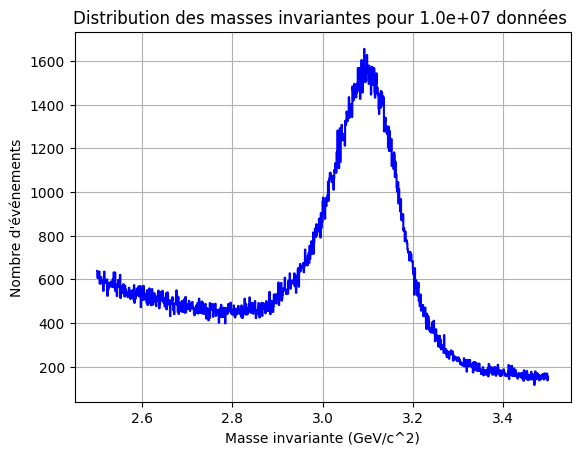

In [4]:
##Bouclage sur les runs
tps = time.time()
#liens = liens[:5] #Pour débuter
results = np.array([])
for lien in liens:
    results = np.concatenate([results, donnees_masses_invarientes(lien)])  #On obtient une liste les données de chaque run 
print("Extraction terminée, on a un total de :", len(results), f"données, ce qui a pris :{(time.time() - tps):.1f} secondes")
graph_masses_invariantes(results)



## Fit sur toutes les données


Paramètres ajustés avec incertitudes :
Paramètre 0: 1.445e+06 ± 6.600e-11
Paramètre 1: -1.533e+00 ± 4.477e-01
Paramètre 2: -1.537e+00 ± 4.620e-01
Paramètre 3: -9.899e-01 ± 1.387e-02
Paramètre 4: 2.582e+02 ± 3.543e+00
Paramètre 5: 3.095e+00 ± 3.337e-04
Paramètre 6: 7.132e-02 ± 3.788e-04
Paramètre 7: 9.449e-01 ± 2.123e-02
Paramètre 8: 9.429e+00 ± 3.637e+00

χ² réduit = 1.314
Intégrale CB2 (signal) = 257564.679 ± 4645.079
Intégrale DE (bruit) = 323.935 ± 719.089
Rapport S/B = 795.112 ± 1765.093


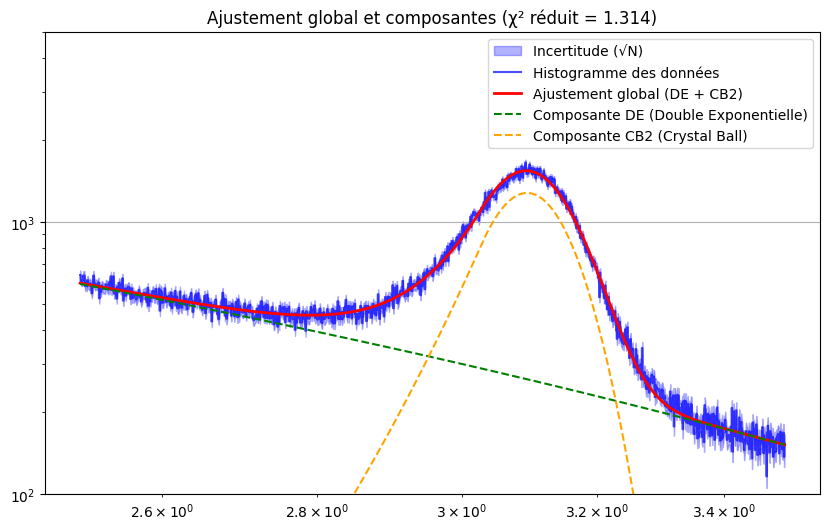

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf

y_data = np.asarray(hist_opposite)

# Filtrer les données sur l'ensemble des bin_centers
x_data = bin_centers
y_errors = np.sqrt(y_data)  # Incertitude : racine du nombre de coups

x_data = np.asarray(x_data)
y_data = np.asarray(y_data)

# Largeur des bins pour correction de l'intégrale
bin_widths = np.diff(bin_edges)  # Largeur de chaque bin

# Définir la fonction Double Exponentielle (DE)
def double_exponential(x, N_de, a1, a2, alpha):
    return N_de * (np.exp(a1 * x) + alpha * np.exp(a2 * x))

# Définir la fonction Crystal Ball (CB2)
def crystal_ball(x, N_cb, mu, sigma, alpha, n):
    t = (x - mu) / sigma
    A = (n / abs(alpha)) ** n * np.exp(-(alpha**2) / 2)
    B = n / abs(alpha) - abs(alpha)
    C = (n / abs(alpha)) / (n - 1) * np.exp(-(alpha**2) / 2)
    D = np.sqrt(np.pi / 2) * (1 + erf(abs(alpha) / np.sqrt(2)))
    norm_factor = sigma * (C + D)
    return np.piecewise(
        t,
        [t > -alpha, t <= -alpha],
        [
            lambda t: N_cb * np.exp(-(t**2) / 2) / norm_factor,
            lambda t: N_cb * A * (B - t) ** (-n) / norm_factor,
        ],
    )

# Définir la fonction globale (DE + CB2)
def combined_function(x, N_de, a1, a2, alpha, N_cb, mu, sigma, alpha_cb, n):
    return double_exponential(x, N_de, a1, a2, alpha) + crystal_ball(
        x, N_cb, mu, sigma, alpha_cb, n
    )

# Paramètres initiaux et bornes
initial_params = [
    1.457e+06, -1.564e+00, -1.564e+00, -9.490e-01, 5.406e+02, 3.089, 7.511e-02, 4.777e+00, 1.000e+01
]
bounds = (
    [0, -np.inf, -np.inf, -10, -101, 1.01, 0.01, 0.1, 1],
    [np.inf, 10, 10, 10, np.inf, 5, 1.0, 5, 10]
)
y_errors = np.where(y_errors == 0, 1e-10, y_errors)  # Éviter les divisions par 0

# Ajustement des paramètres avec estimation de la covariance
try:
    popt, pcov = curve_fit(
        combined_function,
        x_data,
        y_data,
        sigma=y_errors,
        absolute_sigma=True,
        p0=initial_params,
        bounds=bounds,
        maxfev=50000000
    )
except RuntimeError as e:
    print("Erreur d'ajustement :", e)

# Extraire les incertitudes sur les paramètres
param_errors = np.sqrt(np.diag(pcov))

# Générer les courbes ajustées
x_fit = np.linspace(x_data.min(), x_data.max(), len(bin_centers))  # Adapter au nombre de bins
y_fit = combined_function(x_fit, *popt)
y_de = double_exponential(x_fit, *popt[:4])
y_cb2 = crystal_ball(x_fit, *popt[4:])

# Calcul du χ² réduit
y_model = combined_function(x_data, *popt)
chi2 = np.sum(((y_data - y_model) / y_errors) ** 2)
ndof = len(y_data) - len(popt)
chi2_reduced = chi2 / ndof

# **Correction de l'intégration en prenant en compte la largeur des bins**
integration_range = (x_data >= 2.25) & (x_data <= 3.80)

integral_cb2_central = np.sum(y_cb2[integration_range] * bin_widths[integration_range])/(1/bins)
integral_de_central = np.sum(y_de[integration_range] * bin_widths[integration_range])

# Intégrales avec paramètres ± erreurs
popt_high = popt + param_errors
popt_low = popt - param_errors

y_cb2_high = crystal_ball(x_fit, *popt_high[4:])
y_cb2_low = crystal_ball(x_fit, *popt_low[4:])
y_de_high = double_exponential(x_fit, *popt_high[:4])
y_de_low = double_exponential(x_fit, *popt_low[:4])

integral_cb2_high = np.sum(y_cb2_high[integration_range] * bin_widths[integration_range])/(1/bins)
integral_cb2_low = np.sum(y_cb2_low[integration_range] * bin_widths[integration_range])/(1/bins)
integral_de_high = np.sum(y_de_high[integration_range] * bin_widths[integration_range])
integral_de_low = np.sum(y_de_low[integration_range] * bin_widths[integration_range])

# Calcul des incertitudes
integral_cb2_err = max(abs(integral_cb2_central - integral_cb2_high), abs(integral_cb2_central - integral_cb2_low))
integral_de_err = max(abs(integral_de_central - integral_de_high), abs(integral_de_central - integral_de_low))

# Calcul de l'incertitude sur S/B
signal_to_background = integral_cb2_central / integral_de_central if integral_de_central > 0 else np.inf
signal_to_background_err = signal_to_background * np.sqrt(
    (integral_cb2_err / integral_cb2_central)**2 + (integral_de_err / integral_de_central)**2
)

# **Affichage des résultats**
print("\nParamètres ajustés avec incertitudes :")
for i, (param, error) in enumerate(zip(popt, param_errors)):
    print(f"Paramètre {i}: {param:.3e} ± {error:.3e}")

print(f"\nχ² réduit = {chi2_reduced:.3f}")
print(f"Intégrale CB2 (signal) = {integral_cb2_central:.3f} ± {integral_cb2_err:.3f}")
print(f"Intégrale DE (bruit) = {integral_de_central:.3f} ± {integral_de_err:.3f}")
print(f"Rapport S/B = {signal_to_background:.3f} ± {signal_to_background_err:.3f}")

# **Tracer les données et les ajustements**
plt.figure(figsize=(10, 6))

plt.fill_between(
    bin_centers,
    y_data - y_errors,
    y_data + y_errors,
    color="blue",
    alpha=0.3,
    label="Incertitude (√N)",
)
plt.step(bin_centers, y_data, where="mid", label="Histogramme des données", color="blue", alpha=0.7)
plt.plot(x_fit, y_fit, label="Ajustement global (DE + CB2)", color="red", linewidth=2)
plt.plot(x_fit, y_de, label="Composante DE (Double Exponentielle)", color="green", linestyle="--", linewidth=1.5)
plt.plot(x_fit, y_cb2, label="Composante CB2 (Crystal Ball)", color="orange", linestyle="--", linewidth=1.5)

#plt.xlabel("Masse invariante (GeV/c^2)")
#plt.ylabel("Nombre d'événements")
plt.title(f"Ajustement global et composantes (χ² réduit = {chi2_reduced:.3f})")
plt.legend()
plt.grid(True)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e2,5e3)
plt.show()


1000


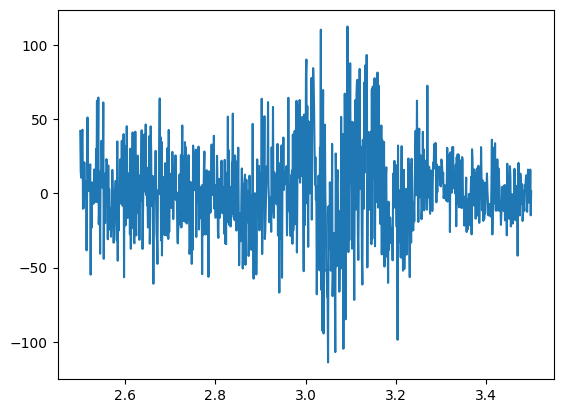

1000


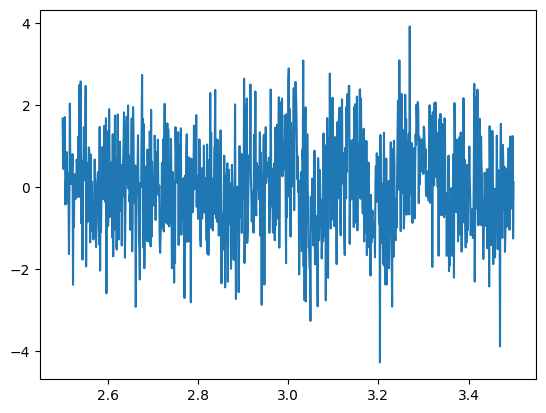

In [6]:
import math
residus = []
for i in range(len(y_data)):
    residus.append(y_data[i]-y_fit[i])
print(len(residus))
plt.plot(x_data,residus)
plt.show()

pull = []
for i in range(len(y_data)):
    pull.append((y_data[i]-y_fit[i])/((y_data[i])**(1/2)))
print(len(pull))
plt.plot(x_data,pull)
plt.show()
